<a href="https://colab.research.google.com/github/LAXMAN7795/Machine-Learning/blob/linear_reg/Linear_Regression(fetch_california_housing).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# fetch_california_housing dataset analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = fetch_california_housing()
dataset = pd.DataFrame(df.data, columns=df.feature_names)#if we specify columns then column name will be seen in output otherwise only column number in index wise

dataset['Target'] = df.target#The target is stored as a NumPy array in the df.target attribute of the dataset object.Each target value represents the median house value (in $100,000s) for a particular block group.
dataset

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


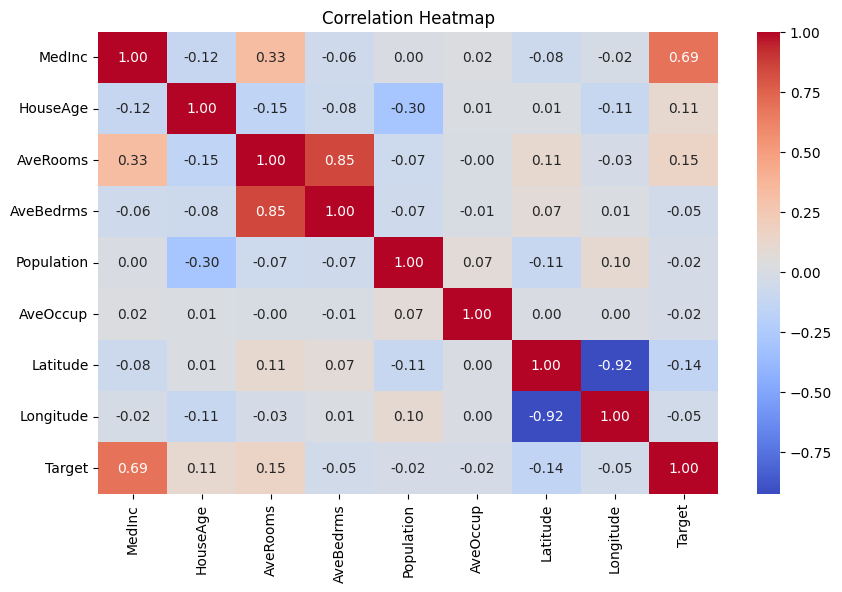

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(dataset.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

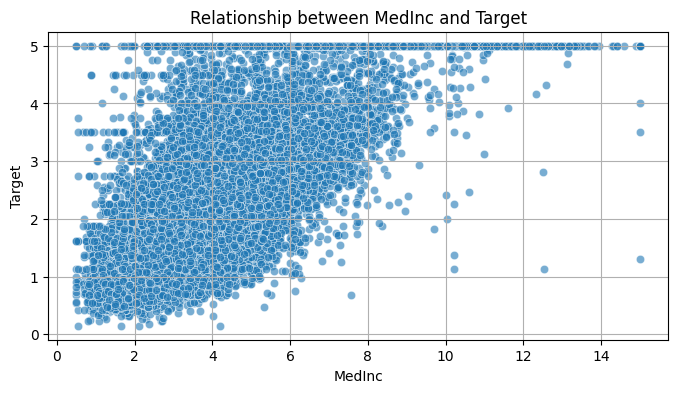

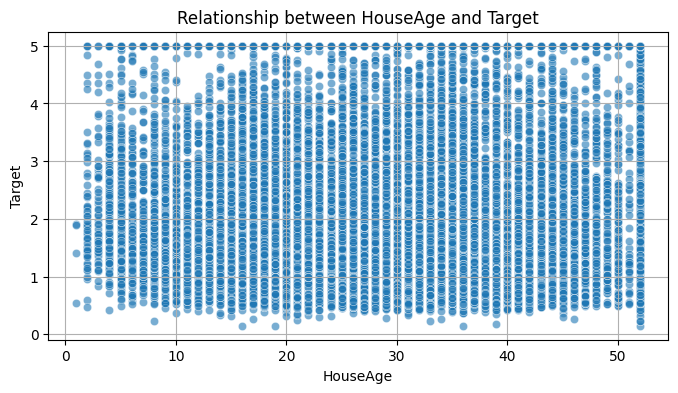

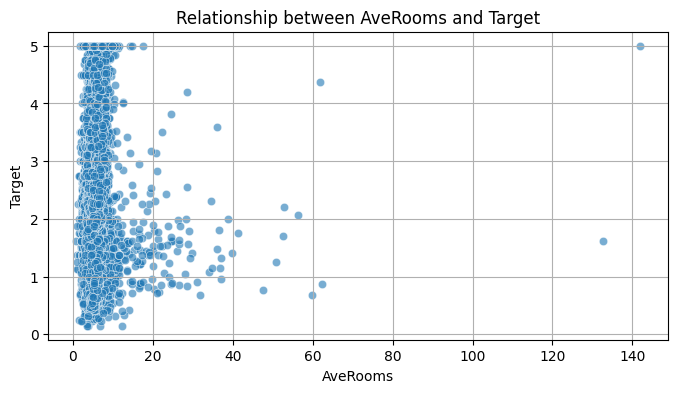

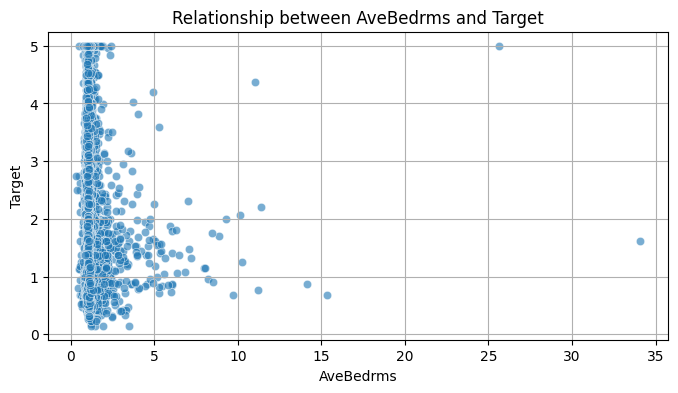

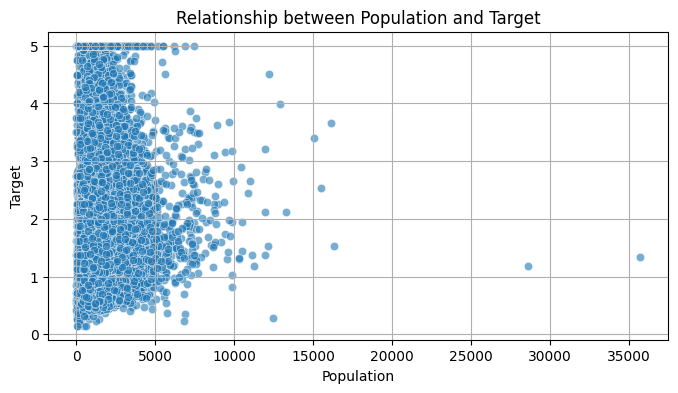

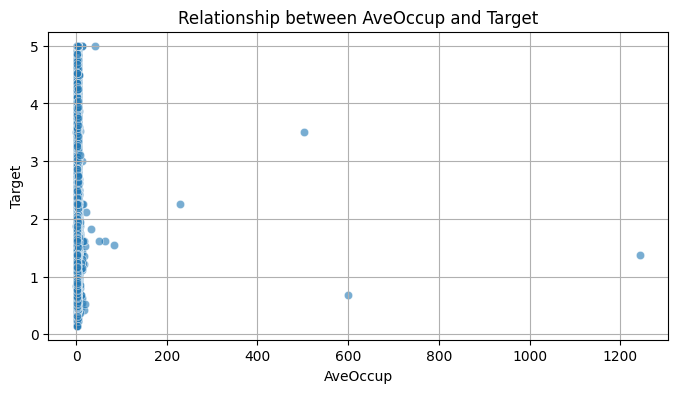

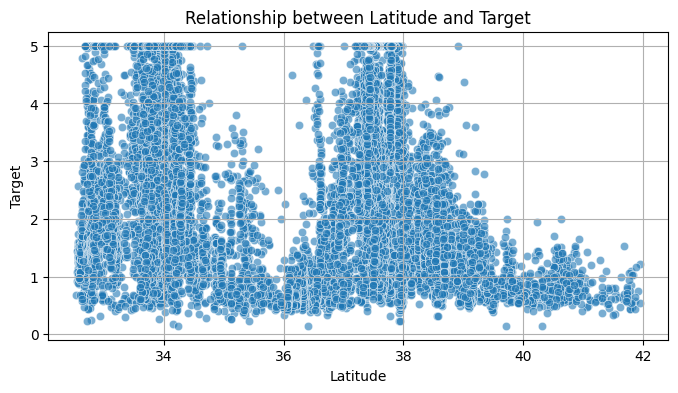

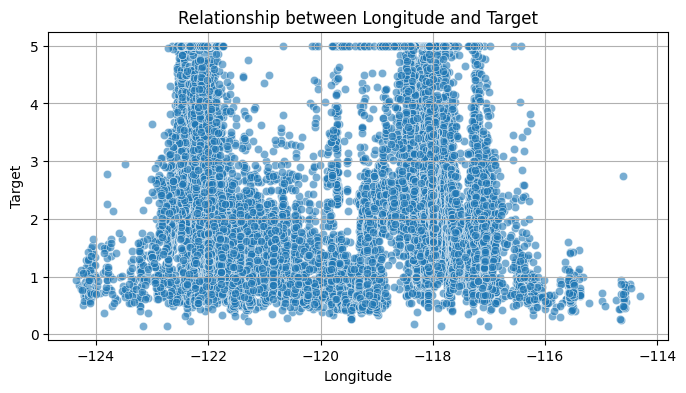

In [ ]:
for feature in df.feature_names:
    plt.figure(figsize=(8, 4))
    sns.scatterplot(data=dataset, x=feature, y='Target', alpha=0.6)
    plt.title(f'Relationship between {feature} and Target')
    plt.xlabel(feature)
    plt.ylabel('Target')
    plt.grid(True)
    plt.show()


In [ ]:
X = dataset.drop(columns=['Target'])#X: Independent variables (features).y: Dependent variable (target).
y = dataset['Target']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42)#Purpose: Splits the data into training (70%) and testing (30%) sets.
#random_state=42: Ensures reproducibility by fixing the random seed.

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
regression = LinearRegression()#LinearRegression(): Initializes a linear regression model.
#fit(): Trains the model by finding the best-fit line for the training data.
regression.fit(X_train, y_train)

LinearRegression()

In [ ]:
cv_scores = cross_val_score(regression, X_train, y_train, scoring='neg_mean_squared_error', cv=10)
mean_cv_mse = -np.mean(cv_scores)
#cross_val_score: Performs 10-fold cross-validation to evaluate model performance on different splits.
#scoring='neg_mean_squared_error': Evaluates performance using negative MSE (minimizing negative MSE is equivalent to minimizing MSE).

In [ ]:
reg_pred = regression.predict(X_test)

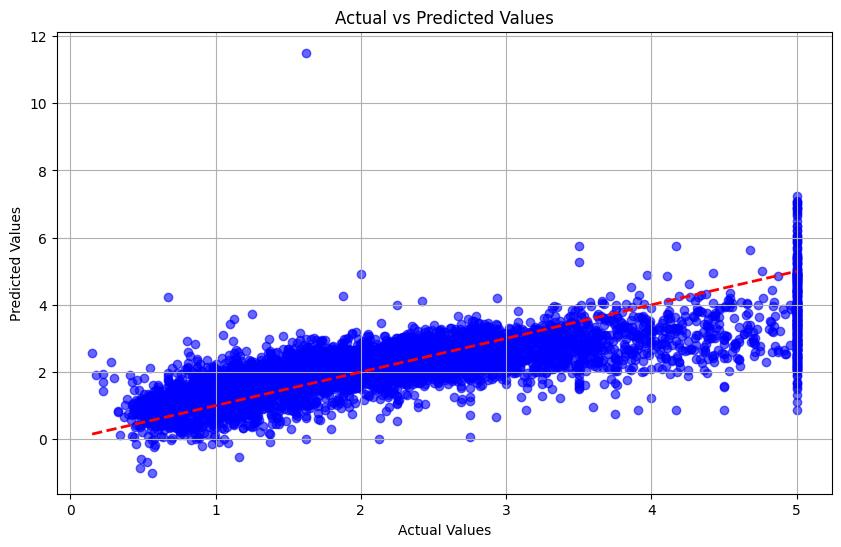

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, reg_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.show()


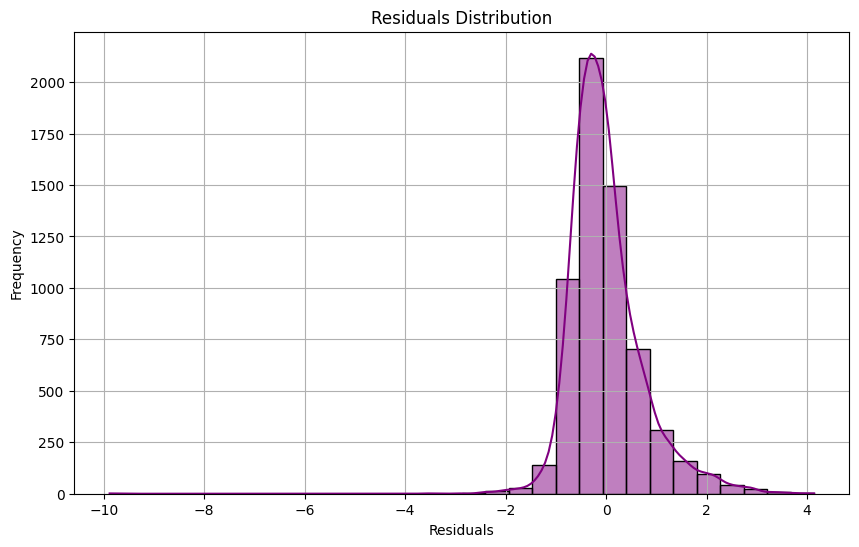

In [ ]:
residuals = y_test - reg_pred

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='purple', bins=30)
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


In [ ]:
mse = mean_squared_error(y_test, reg_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, reg_pred)

print(f"Cross-validated Mean Squared Error (MSE): {mean_cv_mse}")
print(f"Test Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R²): {r2}")


Cross-validated Mean Squared Error (MSE): 0.5257104326777
Test Mean Squared Error (MSE): 0.5305677824766752
Root Mean Squared Error (RMSE): 0.7284008391515452
R-squared (R²): 0.5957702326061664
